In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
from utils.spark_session import get_spark

import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                            confusion_matrix, precision_recall_curve, auc)
from imblearn.over_sampling import SMOTE

spark = get_spark()
GOLD_PATH = '../data/gold'

df_gold_spark = spark.read.format('delta').load(GOLD_PATH)

df = df_gold_spark.toPandas()

print(f'Gold row loaded: {len(df)}')
df.head()

Gold row loaded: 4743


,id,is_violent_recid,v_decile_score,race,age,priors_count14,juv_fel_count,juv_misd_count,is_juvenile_offender,prior_crime_density,high_prior_count,charge_severity_score,sex_binary
0,1,0,1,Other,69,0,0,0,0,0.000000,0,2,1
1,3,1,1,African-American,34,0,0,0,0,0.000000,0,2,1
2,5,0,6,African-American,23,1,0,1,1,0.200000,0,2,1
3,6,0,1,Other,43,2,0,0,0,0.142857,0,2,1
4,7,0,1,Other,44,0,0,0,0,0.000000,0,1,1


In [7]:
FEATURE_COLS = [
    'age',
    'priors_count14',
    'juv_fel_count',
    'juv_misd_count',
    'is_juvenile_offender',
    'prior_crime_density',
    'high_prior_count',
    'charge_severity_score',
    'sex_binary',
]

TARGET_COL = 'is_violent_recid'

X = df[FEATURE_COLS]
y = df[TARGET_COL]

race_series = df['race']

X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race_series,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set: {len(X_train)} rows')
print(f'Test set: {len(X_test)} rows')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test positive rate: {y_test.mean():.3f}')

Training set: 3794 rows
Test set: 949 rows
Train positive rate: 0.173
Test positive rate: 0.173


In [8]:
mlflow.set_tracking_uri('file:../mlruns')
mlflow.set_experiment('recidivai-models')

with mlflow.start_run(run_name='logistic_regression_v1'):
    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_param('max_iter', 1000)
    mlflow.log_param('features', FEATURE_COLS)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    lr_model.fit(X_train_scaled, y_train)

    y_pred_lr = lr_model.predict(X_test_scaled)
    y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

    auc_lr = roc_auc_score(y_test, y_proba_lr)
    f1_lr = f1_score(y_test, y_pred_lr)

    mlflow.log_metric('roc_auc', auc_lr)
    mlflow.log_metric('f1_score', f1_lr)
    mlflow.sklearn.log_model(lr_model, 'model')
    mlflow.sklearn.log_model(scaler, 'scaler')

    print(f'Logistic Regression | AUC: {auc_lr:.4f} | F1: {f1_lr:.4f}')
    print(classification_report(y_test, y_pred_lr))

2026/04/07 10:53:39 INFO mlflow.tracking.fluent: Experiment with name 'recidivai-models' does not exist. Creating a new experiment.
2026/04/07 10:53:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 10:53:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/04/07 10:53:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 10:53:42 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/04/07 10:53:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logistic Regression | AUC: 0.7405 | F1: 0.4372
              precision    recall  f1-score   support

           0       0.90      0.78      0.84       785
           1       0.35      0.57      0.44       164

    accuracy                           0.74       949
   macro avg       0.63      0.68      0.64       949
weighted avg       0.80      0.74      0.77       949



In [9]:
with mlflow.start_run(run_name='random_forest_v1'):
    mlflow.log_param('model_type', 'RandomForest')
    mlflow.log_param('n_estimators', 200)
    mlflow.log_param('max_depth', 10)
    mlflow.log_param('class_weight', 'balanced')

    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)

    y_pred_rf = rf_model.predict(X_test)
    y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

    auc_rf = roc_auc_score(y_test, y_proba_rf)
    f1_rf = f1_score(y_test, y_pred_rf)

    mlflow.log_metric('roc_auc', auc_rf)
    mlflow.log_metric('f1_score', f1_rf)
    mlflow.sklearn.log_model(rf_model, 'model')

    print(f'Random Forest | AUC: {auc_rf:.4f} | F1: {f1_rf:.4f}')
    print(classification_report(y_test, y_pred_rf))

2026/04/07 10:58:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 10:58:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Random Forest | AUC: 0.6786 | F1: 0.4123
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       785
           1       0.38      0.45      0.41       164

    accuracy                           0.78       949
   macro avg       0.63      0.65      0.64       949
weighted avg       0.79      0.78      0.79       949



In [10]:
with mlflow.start_run(run_name='gradient_boosting_v1'):
    mlflow.log_param('model_type', 'GradientBoosting')
    mlflow.log_param('n_estimators', 200)
    mlflow.log_param('learning_rate', 0.1)
    mlflow.log_param('max_depth', 4)

    gbm_model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )
    gbm_model.fit(X_train, y_train)

    y_pred_gbm = gbm_model.predict(X_test)
    y_proba_gbm = gbm_model.predict_proba(X_test)[:, 1]

    auc_gbm = roc_auc_score(y_test, y_proba_gbm)
    f1_gbm = f1_score(y_test, y_pred_gbm)

    mlflow.log_metric('roc_auc', auc_gbm)
    mlflow.log_metric('f1_score', f1_gbm)
    mlflow.sklearn.log_model(gbm_model, 'model')

    print(f'Gradient Boosting | AUC: {auc_gbm:.4f} | F1: {f1_gbm:.4f}')
    print(classification_report(y_test, y_pred_gbm))

2026/04/07 11:05:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 11:05:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Gradient Boosting | AUC: 0.7008 | F1: 0.1756
              precision    recall  f1-score   support

           0       0.84      0.97      0.90       785
           1       0.44      0.11      0.18       164

    accuracy                           0.82       949
   macro avg       0.64      0.54      0.54       949
weighted avg       0.77      0.82      0.77       949



In [11]:
best_model = lr_model
y_pred_best = y_pred_lr

print('=== FAIRNESS ANALYSIS — Best Model vs COMPAS ===')

def compute_fairness_metrics(y_true, y_pred, race):
    results = []
    for group in race.unique():
        mask = race == group
        yt = y_true[mask]
        yp = y_pred[mask]
        n = len(yt)

        tn = ((yt == 0) & (yp == 0)).sum()
        fp = ((yt == 0) & (yp == 1)).sum()
        fn = ((yt == 1) & (yp == 0)).sum()
        tp = ((yt == 1) & (yp == 1)).sum()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        results.append({
            'Race': group,
            'N': n,
            'FPR (our model)': round(fpr, 3),
            'FNR (our model)': round(fnr, 3)
        })

    return pd.DataFrame(results).sort_values('FPR (our model)', ascending=False)

race_test_aligned = race_test.reset_index(drop=True)
y_test_aligned = y_test.reset_index(drop=True)
y_pred_aligned = pd.Series(y_pred_best)

fairness_df = compute_fairness_metrics(y_test_aligned, y_pred_aligned, race_test_aligned)
print(fairness_df.to_string(index=False))

=== FAIRNESS ANALYSIS — Best Model vs COMPAS ===
            Race   N  FPR (our model)  FNR (our model)
African-American 432            0.322            0.330
 Native American   5            0.200            0.000
           Asian   8            0.200            0.333
       Caucasian 353            0.160            0.634
        Hispanic  96            0.112            0.375
           Other  55            0.044            0.600


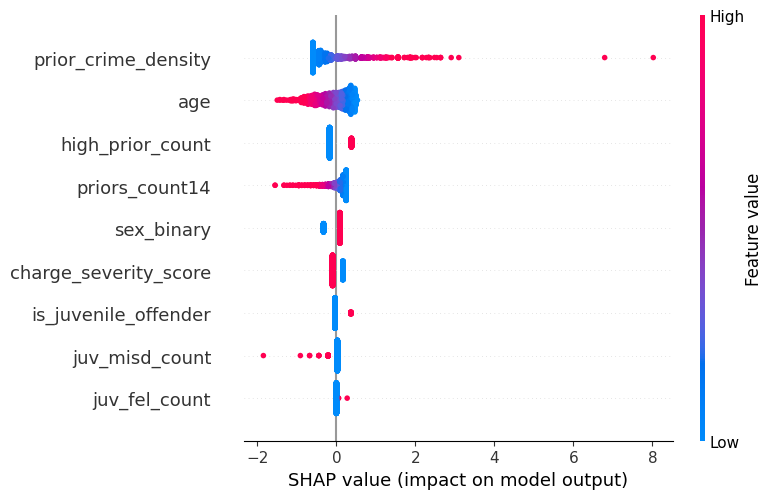

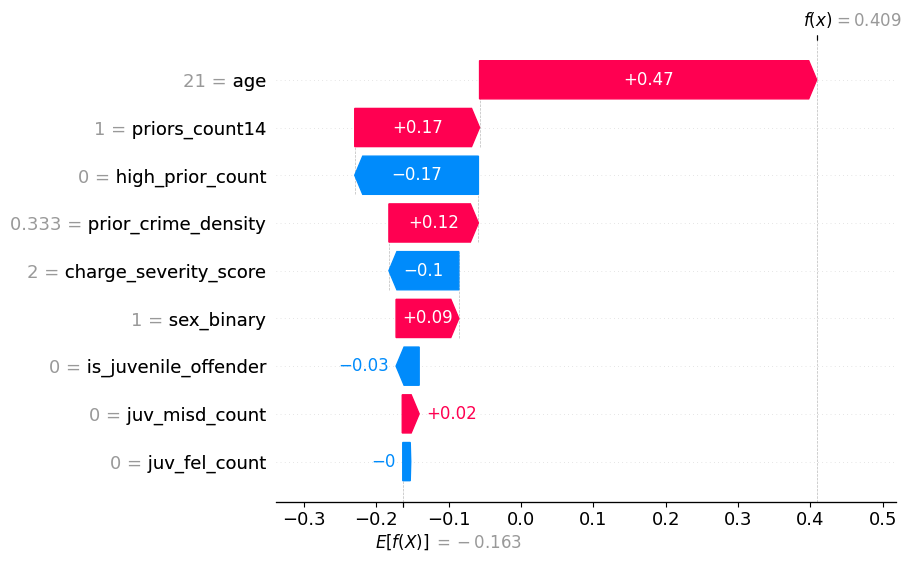

In [12]:
explainer = shap.LinearExplainer(best_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
else:
    shap_values_positive = shap_values

# Plot 1: Global feature importance
shap.summary_plot(
    shap_values_positive,
    X_test,
    feature_names=FEATURE_COLS,
    show=False
)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig('../docs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Waterfall chart for a single prediction
idx = 0
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_positive[idx],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list)
                    else explainer.expected_value,
        data=X_test.iloc[idx],
        feature_names=FEATURE_COLS
    ),
    show=False
)
plt.savefig('../docs/shap_waterfall_example.png', dpi=150, bbox_inches='tight')
plt.show()